# Major Studios Analysis: Quantity vs. Quality & Production Trends

## Analysis Objective
This analysis aims to explore the landscape of Japanese animation studios by answering three fundamental questions:
1. **Who dominates the market?** Identifying the most prolific studios in terms of production volume.
2. **Who guarantees quality?** Identifying the studios that maintain the highest average ratings.
3. **How has production evolved?** Analyzing the trend of anime production over the years.

The analysis cross-references production data (from the SQL database) with user scores (from the processed Parquet dataset).

In [123]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import lib.dbconnection as dbc

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Ingestion

We load data from two separate sources to optimize performance:
* **Ratings (Parquet):** We use `DuckDB` to quickly aggregate millions of votes and calculate the average score per anime.
* **Metadata (SQL):** We retrieve studio and air date details from the `details` table in the Postgres database.

In [124]:
PARQUET_PATH = '../../../cleaned_data/ratings_cleaned.parquet'
engine = dbc.create_db_engine()

# 1. Score Aggregation with DuckDB (Very fast on large volumes)
query_scores = f"""
    SELECT
        anime_id,
        AVG(score) as avg_score,
        COUNT(score) as vote_count
    FROM read_parquet('{PARQUET_PATH}')
    WHERE score > 0
    GROUP BY anime_id
"""
df_scores = duckdb.sql(query_scores).df()

# 2. Load Studio Details from SQL
# Note: The 'studios' column was already cleaned in the '2_Dataset_Cleaning' notebook
query_details = "SELECT mal_id as anime_id, studios FROM details"
df_details = pd.read_sql(query_details, engine)

# 3. Merge Datasets
# We only join anime for which we have both studio and rating data
df_merged = pd.merge(df_scores, df_details, on='anime_id', how='inner')

# Remove any rows with missing or null studios
df_merged.dropna(subset=['studios'], inplace=True)
df_merged = df_merged[df_merged['studios'] != ''] # Remove empty strings if present

print(f"Dataset ready. Analysis on {len(df_merged)} anime with complete data.")

Dataset ready. Analysis on 17005 anime with complete data.


## 2. Calculating Studio Metrics

To obtain statistically relevant results, we apply the following criteria:
1. **Aggregation:** We group data by `studios`, calculating the work count and average score.
2. **Relevance Threshold:** We filter out studios that have produced fewer than **10 works**. This eliminates "one-hit wonders".

In [125]:
# Data aggregation by studio
studio_stats = df_merged.groupby('studios').agg(
    work_count=('anime_id', 'count'),
    avg_studio_score=('avg_score', 'mean'),
    total_votes=('vote_count', 'sum') # Useful for extra context
).reset_index()

# Set minimum works threshold for analysis
MIN_WORKS = 10

# Statistical filtering
top_studios = studio_stats[studio_stats['work_count'] >= MIN_WORKS]

# Create Top 15 lists
top_15_by_works = top_studios.sort_values(by='work_count', ascending=False).head(15)
top_15_by_score = top_studios.sort_values(by='avg_studio_score', ascending=False).head(15)

print(f"Studios analyzed (with at least {MIN_WORKS} works): {len(top_studios)}")

Studios analyzed (with at least 10 works): 279


## 3. Results Visualization

### 3.1 The Production Giants
The following chart shows the studios with the largest number of titles in their catalog.

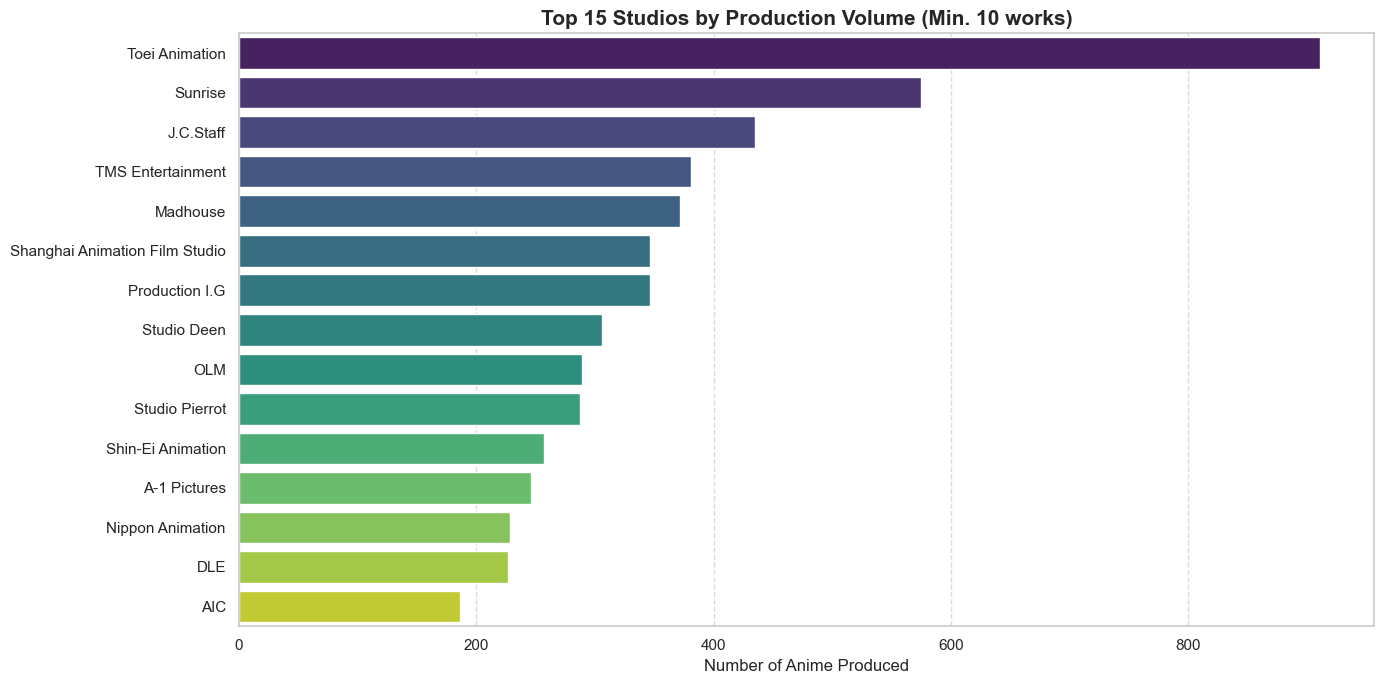

In [126]:
plt.figure(figsize=(14, 7))
barplot = sns.barplot(
    data=top_15_by_works,
    x='work_count',
    y='studios',
    palette='viridis' ,
    hue='studios'
)
plt.title(f'Top 15 Studios by Production Volume (Min. {MIN_WORKS} works)', fontsize=15, weight='bold')
plt.xlabel('Number of Anime Produced', fontsize=12)
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../../graphs/top_studios_volume.png', dpi=300)
plt.show()

### 3.2 The Standard-Bearers of Quality
Here, we highlight the studios that maintain the highest average scores.

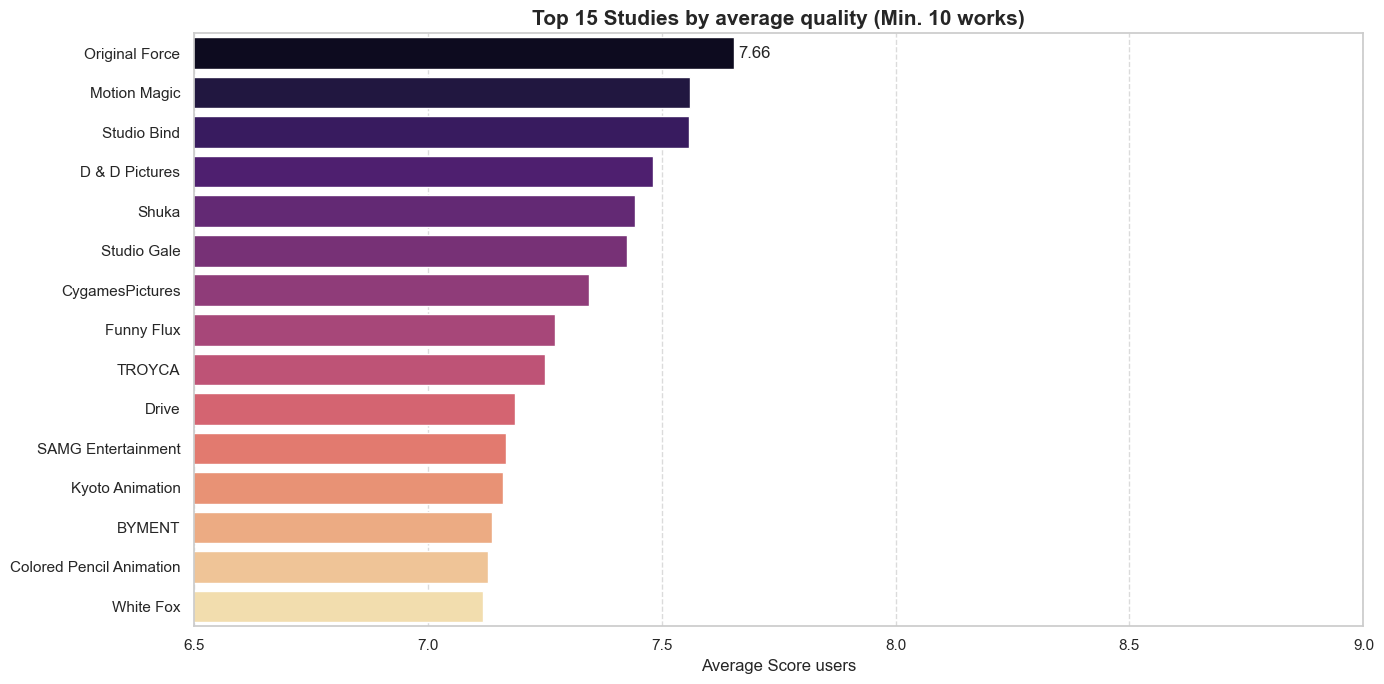

In [127]:
plt.figure(figsize=(14, 7))
barplot_score = sns.barplot(
    data=top_15_by_score,
    x='avg_studio_score',
    y='studios',
    palette='magma',
    hue='studios'
)

barplot_score.bar_label(barplot_score.containers[0], fmt='%.2f', padding=3)

plt.title(f'Top 15 Studies by average quality (Min. {MIN_WORKS} works)', fontsize=15, weight='bold')
plt.xlabel('Average Score users', fontsize=12)
plt.ylabel('', fontsize=12)
plt.xlim(6.5, 9.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../../graphs/production_over_time.png', dpi=300)
plt.show()